In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRFcLuAQ8O1J-1l3otAYB4k2duqlGPiHpkw0GOIAfFTfR2v3hop6rChLKVJb7hkDuVJNNC6G5gusN8q/pub?output=csv"
df = pd.read_csv(url, header=0)
df

,طابع زمني,? What are your preferred sports,? How many pets do you have at home,What is your mode of transportation when traveling to school ?
0,4:15:11 م 2025/03/22,Football,0,Public Bus
1,4:15:28 م 2025/03/22,Football,Zero,Car
2,4:15:57 م 2025/03/22,Swimming,1,Bus
3,4:17:49 م 2025/03/22,Football,None,Bus
4,4:23:48 م 2025/03/22,Football,0,Bus
5,4:25:30 م 2025/03/22,Football,1,Public transportation
6,4:25:48 م 2025/03/22,Football,Zero,Bus
7,4:29:09 م 2025/03/22,Running,0,Bus
8,4:29:33 م 2025/03/22,volleyball and ping pong,1,bus
9,4:29:50 م 2025/03/22,SWIMMING,1,Public transportation


In [129]:
df.columns = ["Timestamp", "Preferred Sports", "Number of Pets", "Transportation Mode"]
df

,Timestamp,Preferred Sports,Number of Pets,Transportation Mode
0,4:15:11 م 2025/03/22,Football,0,Public Bus
1,4:15:28 م 2025/03/22,Football,Zero,Car
2,4:15:57 م 2025/03/22,Swimming,1,Bus
3,4:17:49 م 2025/03/22,Football,None,Bus
4,4:23:48 م 2025/03/22,Football,0,Bus
5,4:25:30 م 2025/03/22,Football,1,Public transportation
6,4:25:48 م 2025/03/22,Football,Zero,Bus
7,4:29:09 م 2025/03/22,Running,0,Bus
8,4:29:33 م 2025/03/22,volleyball and ping pong,1,bus
9,4:29:50 م 2025/03/22,SWIMMING,1,Public transportation


# Data Cleaning

In [130]:
df["Number of Pets"] = df["Number of Pets"].astype(str)
df["Number of Pets"] = df["Number of Pets"].replace({"Zero": "0", "None": "0", "I don't have any pets": "0"})
df["Number of Pets"] = pd.to_numeric(df["Number of Pets"])
df

,Timestamp,Preferred Sports,Number of Pets,Transportation Mode
0,4:15:11 م 2025/03/22,Football,0,Public Bus
1,4:15:28 م 2025/03/22,Football,0,Car
2,4:15:57 م 2025/03/22,Swimming,1,Bus
3,4:17:49 م 2025/03/22,Football,0,Bus
4,4:23:48 م 2025/03/22,Football,0,Bus
5,4:25:30 م 2025/03/22,Football,1,Public transportation
6,4:25:48 م 2025/03/22,Football,0,Bus
7,4:29:09 م 2025/03/22,Running,0,Bus
8,4:29:33 م 2025/03/22,volleyball and ping pong,1,bus
9,4:29:50 م 2025/03/22,SWIMMING,1,Public transportation


In [131]:
df["Transportation Mode"] = df["Transportation Mode"].str.lower()

In [132]:
df["Transportation Mode"] = df["Transportation Mode"].replace({
    "public bus": "public transportation",
    "microbus": "bus",
    "on foot": "walking"
})

df

,Timestamp,Preferred Sports,Number of Pets,Transportation Mode
0,4:15:11 م 2025/03/22,Football,0,public bus
1,4:15:28 م 2025/03/22,Football,0,car
2,4:15:57 م 2025/03/22,Swimming,1,bus
3,4:17:49 م 2025/03/22,Football,0,bus
4,4:23:48 م 2025/03/22,Football,0,bus
5,4:25:30 م 2025/03/22,Football,1,public transportation
6,4:25:48 م 2025/03/22,Football,0,bus
7,4:29:09 م 2025/03/22,Running,0,bus
8,4:29:33 م 2025/03/22,volleyball and ping pong,1,bus
9,4:29:50 م 2025/03/22,SWIMMING,1,public transportation


In [133]:
df["Preferred Sports"] = df["Preferred Sports"].str.lower()

# Function to extract main sports from text
def extract_sports(text):
    main_sports = ["football", "swimming", "running", "volleyball", "tennis", 
                   "basketball", "chess", "ping pong", "horse riding", "mma", "hunting"]
    sports_found = []
    for sport in main_sports:
        if sport in text:
            sports_found.append(sport)
    return sports_found if sports_found else [text]

df["Sports List"] = df["Preferred Sports"].apply(extract_sports)

df

,Timestamp,Preferred Sports,Number of Pets,Transportation Mode,Sports List
0,4:15:11 م 2025/03/22,football,0,public bus,[football]
1,4:15:28 م 2025/03/22,football,0,car,[football]
2,4:15:57 م 2025/03/22,swimming,1,bus,[swimming]
3,4:17:49 م 2025/03/22,football,0,bus,[football]
4,4:23:48 م 2025/03/22,football,0,bus,[football]
5,4:25:30 م 2025/03/22,football,1,public transportation,[football]
6,4:25:48 م 2025/03/22,football,0,bus,[football]
7,4:29:09 م 2025/03/22,running,0,bus,[running]
8,4:29:33 م 2025/03/22,volleyball and ping pong,1,bus,"[volleyball, ping pong]"
9,4:29:50 م 2025/03/22,swimming,1,public transportation,[swimming]


In [134]:
transport_counts = df["Transportation Mode"].value_counts()
print(transport_counts)

bus                      11
car                       5
public transportation     2
train                     2
public bus                1
taxi                      1
walking                   1
Name: Transportation Mode, dtype: int64


<module 'matplotlib.pyplot' from 'C:\\Users\\core2duo\\anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

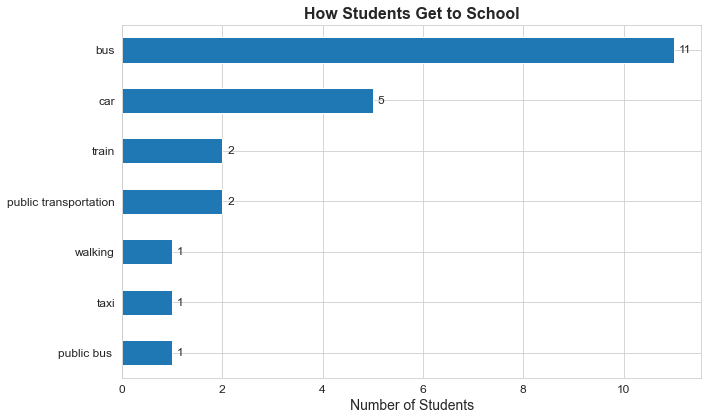

In [137]:
transport_counts = df["Transportation Mode"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = transport_counts.plot(kind='barh')
plt.title('How Students Get to School', fontweight='bold')
plt.xlabel('Number of Students')
plt.ylabel('')  

for i, v in enumerate(transport_counts):
    plt.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('transportation_improved.png', dpi=300)
plt

<module 'matplotlib.pyplot' from 'C:\\Users\\core2duo\\anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

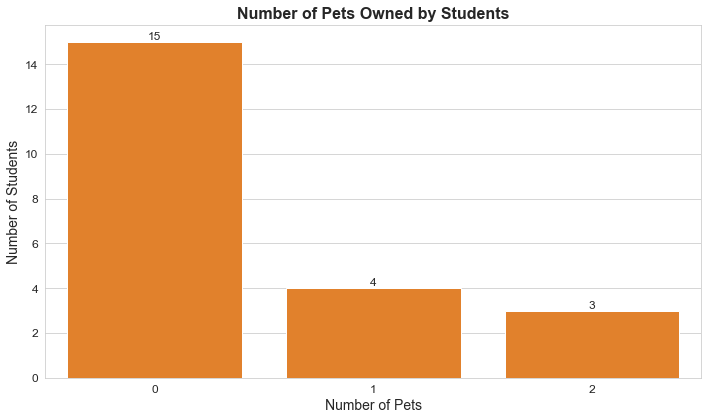

In [119]:
pets_counts = df["Number of Pets"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=pets_counts.index, y=pets_counts.values, palette=[colors[1]] * len(pets_counts))
plt.title('Number of Pets Owned by Students', fontweight='bold')
plt.xlabel('Number of Pets')
plt.ylabel('Number of Students')

for i, v in enumerate(pets_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt

In [120]:
all_sports = [sport for sublist in df["Sports List"] for sport in sublist]
sports_counts = pd.Series(all_sports).value_counts()

<module 'matplotlib.pyplot' from 'C:\\Users\\core2duo\\anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

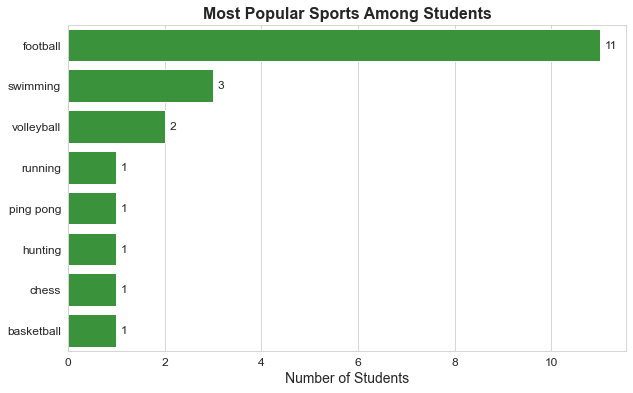

In [138]:
top_sports = sports_counts.head(8)

plt.figure(figsize=(10, 6))
ax = sns.barplot(y=top_sports.index, x=top_sports.values, palette=[colors[2]] * len(top_sports), orient='h')
plt.title('Most Popular Sports Among Students', fontweight='bold')
plt.xlabel('Number of Students')
plt.ylabel('')  

# Add count labels
for i, v in enumerate(top_sports.values):
    ax.text(v + 0.1, i, str(v), va='center')

plt

In [139]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

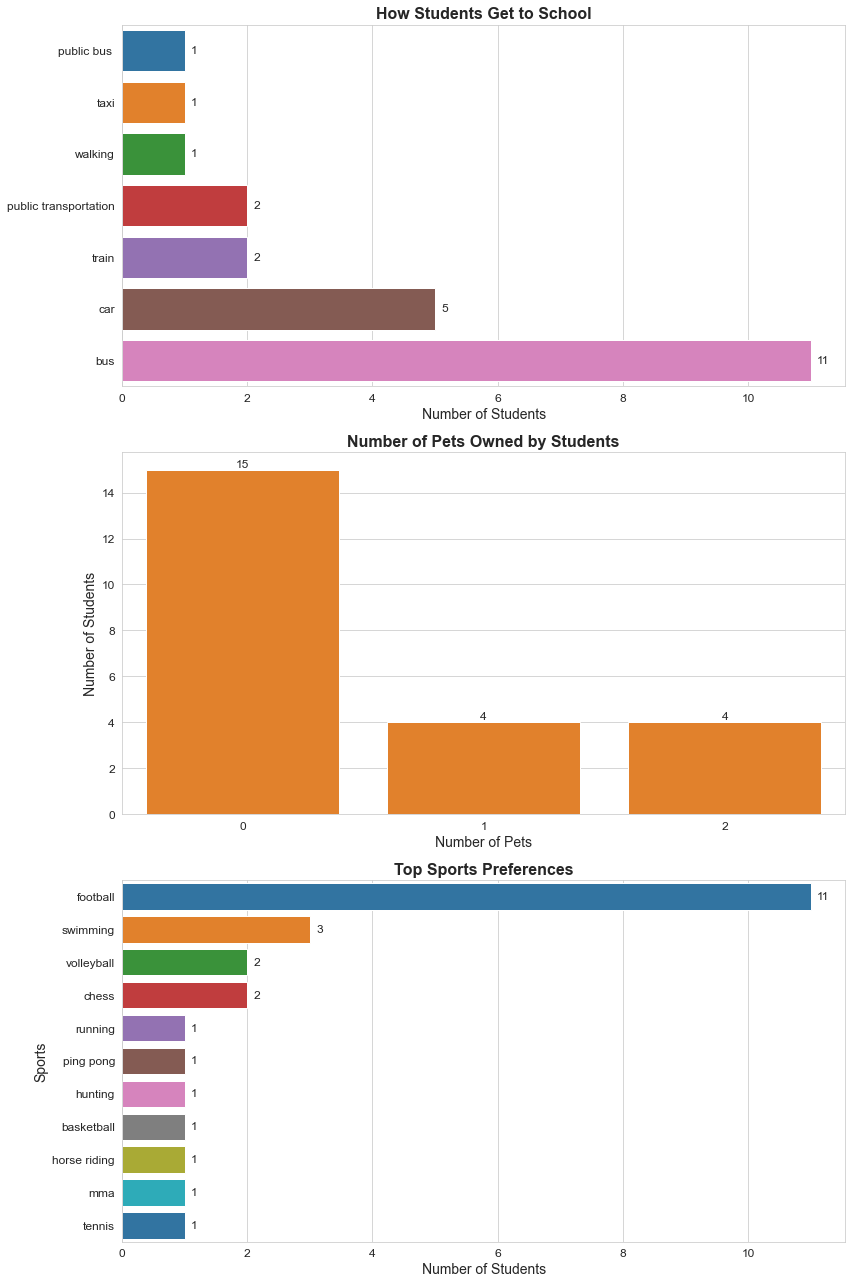

In [140]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Transportation Mode
transport_counts = df["Transportation Mode"].value_counts().sort_values(ascending=True)
sns.barplot(x=transport_counts.values, y=transport_counts.index, ax=axes[0], palette=colors)
axes[0].set_title('How Students Get to School', fontweight='bold')
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('')
for i, v in enumerate(transport_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center')

# Plot 2: Number of Pets
pets_counts = df["Number of Pets"].value_counts().sort_index()
sns.barplot(x=pets_counts.index, y=pets_counts.values, ax=axes[1], palette=[colors[1]] * len(pets_counts))
axes[1].set_title('Number of Pets Owned by Students', fontweight='bold')
axes[1].set_xlabel('Number of Pets')
axes[1].set_ylabel('Number of Students')
for i, v in enumerate(pets_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha='center')

# Plot 3: Sports Preference
all_sports = [sport for sublist in df["Sports List"] for sport in sublist]
sports_counts = pd.Series(all_sports).value_counts()
sns.barplot(x=sports_counts.values, y=sports_counts.index, ax=axes[2], palette=colors)
axes[2].set_title('Top Sports Preferences', fontweight='bold')
axes[2].set_xlabel('Number of Students')
axes[2].set_ylabel('Sports')
for i, v in enumerate(sports_counts.values):
    axes[2].text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [141]:
pastel_colors = ["#A6CEE3", "#B2DF8A", "#FB9A99", "#FDBF6F", "#CAB2D6", "#FFFF99", "#B15928", "#FF7F00", "#6A3D9A", "#1F78B4"]

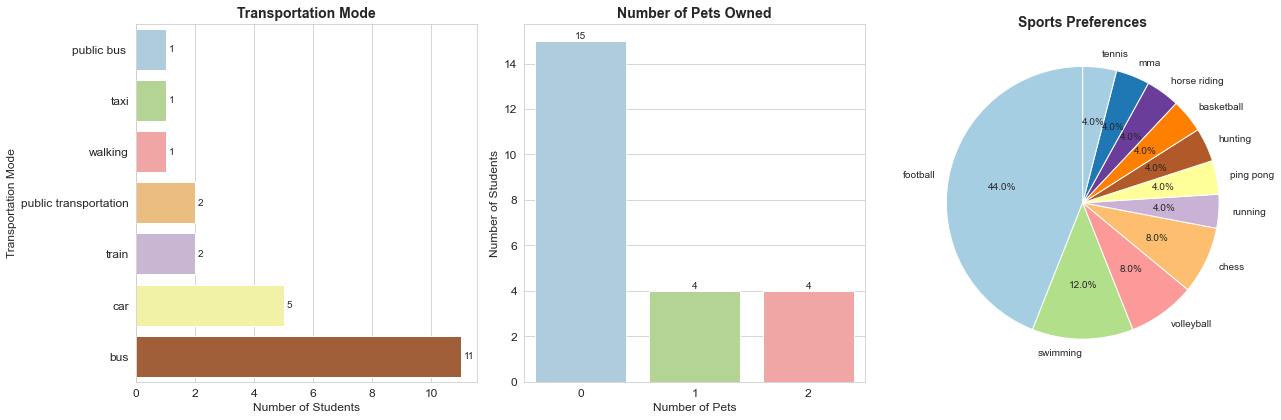

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Transportation Mode (Bar Chart)
transport_counts = df["Transportation Mode"].value_counts().sort_values(ascending=True)
sns.barplot(x=transport_counts.values, y=transport_counts.index, ax=axes[0], palette=pastel_colors)
axes[0].set_title('Transportation Mode', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Number of Students', fontsize=12)
axes[0].set_ylabel('Transportation Mode', fontsize=12)
for i, v in enumerate(transport_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# Plot 2: Number of Pets (Bar Chart)
pets_counts = df["Number of Pets"].value_counts().sort_index()
sns.barplot(x=pets_counts.index, y=pets_counts.values, ax=axes[1], palette=pastel_colors)
axes[1].set_title('Number of Pets Owned', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Number of Pets', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
for i, v in enumerate(pets_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)

# Plot 3: Sports Preference (Pie Chart)
all_sports = [sport for sublist in df["Sports List"] for sport in sublist]
sports_counts = pd.Series(all_sports).value_counts()
axes[2].pie(sports_counts.values, labels=sports_counts.index, autopct='%1.1f%%', startangle=90, colors=pastel_colors, textprops={'fontsize': 10})
axes[2].set_title('Sports Preferences', fontweight='bold', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()

## SHIT COLORS

In [155]:
sequential_colors = sns.color_palette("Blues_d", n_colors=10)

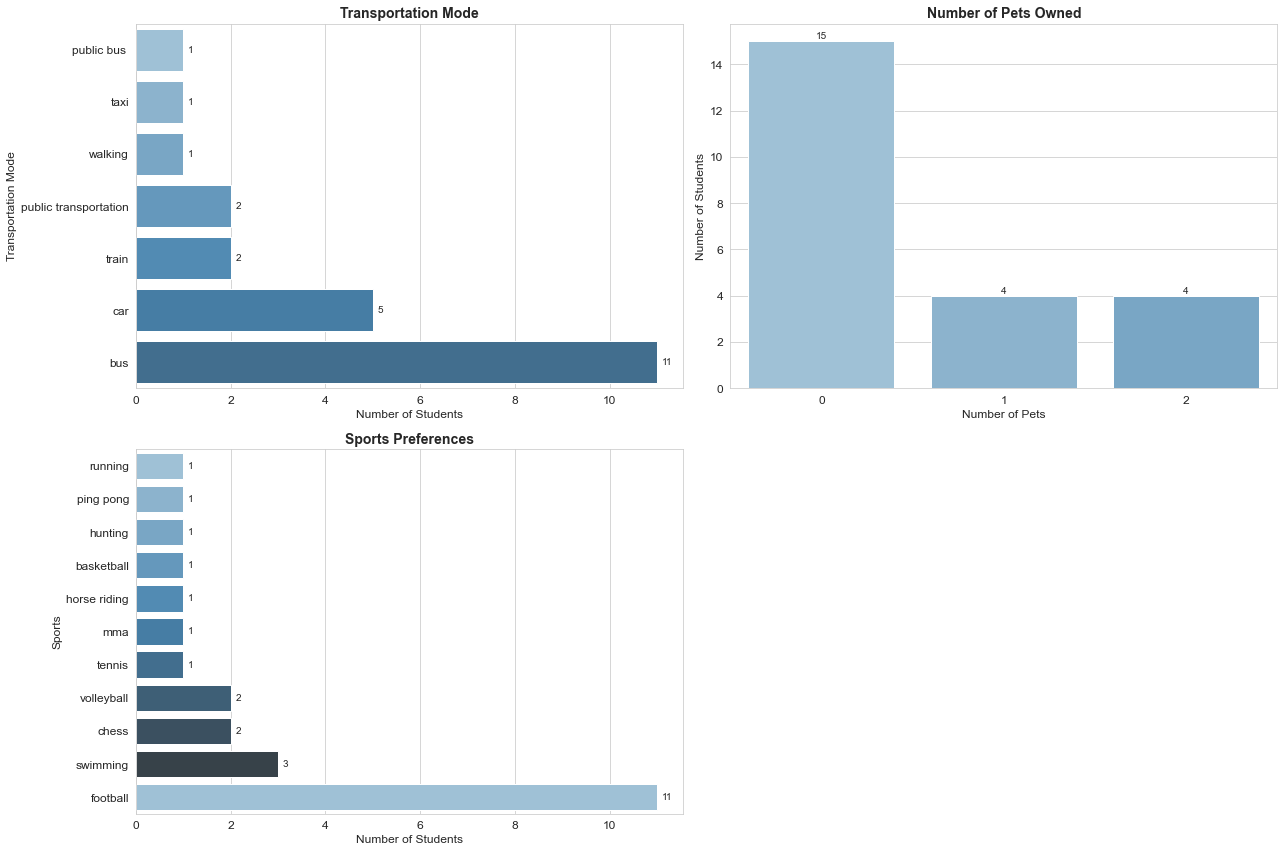

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Transportation Mode (Bar Chart)
transport_counts = df["Transportation Mode"].value_counts().sort_values(ascending=True)
sns.barplot(x=transport_counts.values, y=transport_counts.index, ax=axes[0, 0], palette=sequential_colors)
axes[0, 0].set_title('Transportation Mode', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Number of Students', fontsize=12)
axes[0, 0].set_ylabel('Transportation Mode', fontsize=12)
for i, v in enumerate(transport_counts.values):
    axes[0, 0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# Plot 2: Number of Pets (Bar Chart)
pets_counts = df["Number of Pets"].value_counts().sort_index()
sns.barplot(x=pets_counts.index, y=pets_counts.values, ax=axes[0, 1], palette=sequential_colors)
axes[0, 1].set_title('Number of Pets Owned', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Number of Pets', fontsize=12)
axes[0, 1].set_ylabel('Number of Students', fontsize=12)
for i, v in enumerate(pets_counts.values):
    axes[0, 1].text(i, v + 0.1, str(v), ha='center', fontsize=10)

# Plot 3: Sports Preferences (Bar Chart)
all_sports = [sport for sublist in df["Sports List"] for sport in sublist]
sports_counts = pd.Series(all_sports).value_counts().sort_values(ascending=True)
sns.barplot(x=sports_counts.values, y=sports_counts.index, ax=axes[1, 0], palette=sequential_colors)
axes[1, 0].set_title('Sports Preferences', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Number of Students', fontsize=12)
axes[1, 0].set_ylabel('Sports', fontsize=12)
for i, v in enumerate(sports_counts.values):
    axes[1, 0].text(v + 0.1, i, str(v), va='center', fontsize=10)

axes[1, 1].axis('off') 
plt.tight_layout()
plt.show()